## Caso 2D: Falla a lo largo de Chile Central

Implementando el teorema de Karhunen-Loeve, en este, caso a una matriz de correlación que estará compuesta por:
### $C_{ij}=exp(-(d_{strike}(i,j)/r_{strike})-(d_{dip}(i,j)/r_{dip}))  $

En dónde $d_{strike}(i,j)$ y $d_{dip}(i,j)$ son estimados de la distancia entre subfallas i y j en el strike y dip respectivamente, y $r_{strike}$ y r_{dip} son los largos de correlación en cada dirección.

Se define $d_{dip}(i,j)$ usando la diferencia en profundidad entre dos subfallas y el angulo de dip como

$d_{dip}(i,j)=d_{depth}/sin(dip)$. Configurando $d_{strike}=\sqrt{d_{ij}^2-d_{dip}(i,j)^2}$

Los largo de correlación serán el 40% del largo y ancho de la falla.

## Datos de la falla:
Largo = 500 km
Ancho = 200 km

In [1]:
import sys
sys.path.append('../')
import stochpy
import numpy as np
import matplotlib.pyplot as plt
import pygmt

Se ingresan las cantidades de subfallas, a lo largo del dip y a lo largo del strike, nx y ny

In [2]:
nx=20
ny=50
width=200
length=500

Primero, se cargarán lo datos del trench de Chile, para realizar una geometría paralela a ella

También, se cargarán los archivos de Slab2, que contienen los parámetros geométricos de la zona de subducción de Sudamérica

In [3]:
route_trench = "../auxiliar/trench-chile.txt"
lons_fosa, lats_fosa  = stochpy.load_trench(route_trench)
# load slab files
slabdep,slabdip,slabstrike,slabrake=stochpy.load_files_slab2(zone='south_america',rake=True)

Se realiza la falla a lo largo del trench, y se le da el valor más al norte de la falla. 

Luego, se deben tener las profundidades en cada subfalla, para ello se interpolan los datos de Slab2 con stochpy.interp_slabtofault

In [4]:
north=-29.5
lons,lons_ep,lats,lats_ep=stochpy.make_fault_alongtrench(lons_fosa,lats_fosa,north, nx,ny,width,length)
[X_grid,Y_grid,dep,dip,strike,rake]=stochpy.interp_slabtofault(lons,lats,nx,ny,slabdep,slabdip,slabstrike,slabrake)

##### Se crea la matriz de slips medios con stochpy.matriz_media(mean,dep)

7.0


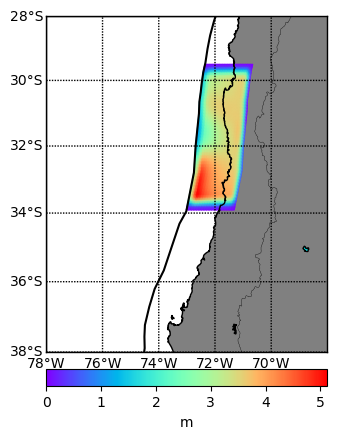

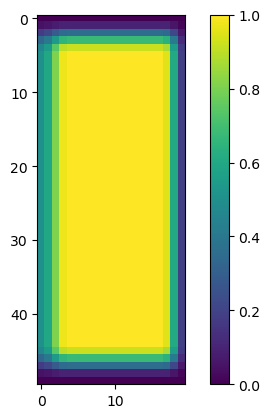

In [15]:

## Creation slip models
# mean matrix
#
Mw=9.0
media=stochpy.media_slip(Mw,length*1000,width*1000,dep)
print(np.trunc(media))
mu=stochpy.matriz_medias(media,dep)
#
C    = stochpy.matriz_covarianza_optimized(dip, dep, X_grid, Y_grid,length*1000,width*1000,alpha=0.5)
# C    = slgen.matriz_covarianza(dip, dep, X_grid, Y_grid)
# for comcot simulation
Slip=stochpy.distribucion_slip(C, mu, 10)
# ventana = slgen.ventana_taper_slip_fosa(Slip, X_grid,Y_grid,2) # ventana de taper
# Slip    = slgen.taper_slip_fosa(Slip,ventana)
Slip,taper_2d    = stochpy.taper_except_trench_tukey(Slip,alpha_dip=0.35,alpha_strike=0.2)
Slip    = stochpy.escalar_magnitud_momento(Mw, Slip, dep, X_grid, Y_grid,prem=True)
Slip[Slip<0]=0
#
# PLOT result
fig=stochpy.plot_slip(X_grid,Y_grid,lons_fosa,lats_fosa,Slip,None,show=True)
plt.imshow(taper_2d)
plt.colorbar()
# fig.subplots_adjust(left=1, right=1.1, top=1.1, bottom=1)
# ax2=fig.add_subplot(122)
# im2=ax2.imshow(taper_2d)
# ax2.set_title('Taper 2d')
# # add space for colour bar
# fig.subplots_adjust(left=-0.5, right=1.1)
# cbar_ax = fig.add_axes([0.88, 0.15, 0.04, 0.7])
# fig.colorbar(im2, cax=cbar_ax)
# fig.show()
# fig.savefig('hola.png')

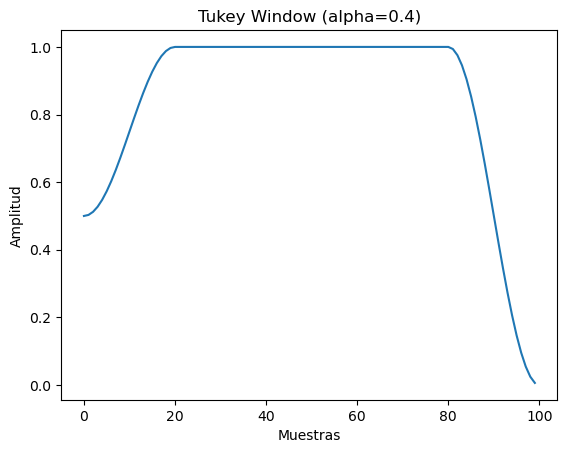

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def tukey_window(N, alpha=0.5):
    """
    Genera una ventana Tukey.

    Parámetros:
    - N: Longitud de la ventana.
    - alpha: Parámetro de apertura (0 para una ventana rectangular, 1 para una ventana Hann).

    Retorna:
    - Ventana Tukey.
    """
    if alpha <= 0:
        return np.ones(N)
    elif alpha >= 1:
        return np.hanning(N)
    else:
        x = np.linspace(0, 1, N, endpoint=False)
        w = np.ones_like(x)

        # Aplica la parte de la ventana Hann
        first_condition = x < alpha / 2
        last_condition = x >= 1 - alpha / 2

        w[first_condition] = 0.5 * (1 + np.cos(2 * np.pi / alpha * (x[first_condition] - alpha / 2)))
        w[last_condition] = 0.5 * (1 + np.cos(2 * np.pi / alpha * (x[last_condition] - 1 + alpha / 2)))

        # Ajusta los valores para que no alcancen completamente cero al comienzo y al final
        w[first_condition] = 0.5 + 0.5 * w[first_condition]
        w[last_condition] = 0 + 1 * w[last_condition]

        return w

# Ejemplo de uso
N = 100
alpha = 0.4
tukey = tukey_window(N, alpha)

# Visualización de la ventana Tukey
plt.plot(tukey)
plt.title(f'Tukey Window (alpha={alpha})')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.show()


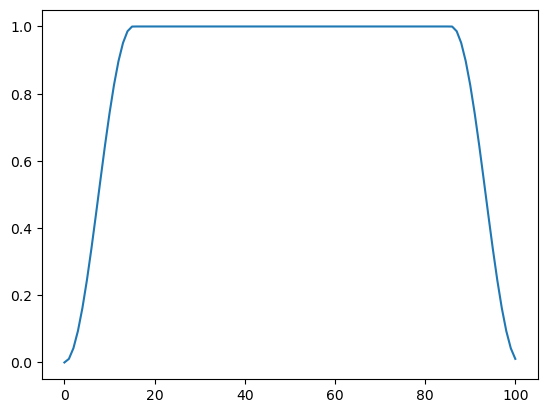

In [7]:
import scipy
window=scipy.signal.windows.tukey(101, alpha=0.3, sym=False)
plt.plot(window)